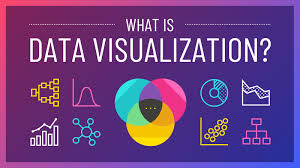

## 🥸 Exploratory data analysis

### 🎒 Packages

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option('display.max_colwidth', None)
import random

---

### 🚙 Utilities

In [2]:
train_path = Path("..") / "data" / "train.csv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test.csv"
# store
store_path = Path("..") / "data" / "store.csv"

In [3]:
pastel_colors = sns.color_palette("pastel")

def color():
    color = random.choice(pastel_colors)
    return color

---

### 📊 Data

#### 🫦 Problem of mixed types

In [4]:
train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], )

/tmp/ipykernel_61401/3960130451.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], )


In [5]:
train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], low_memory=False)
test = pd.read_csv(filepath_or_buffer=test_path, parse_dates=["Date"])
store = pd.read_csv(filepath_or_buffer=store_path)

In [6]:
store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
train.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [8]:
test.head(5)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [9]:
test.describe()

,Id,Store,DayOfWeek,Date,Open,Promo,SchoolHoliday
count,41088.000000,41088.000000,41088.000000,41088,41077.000000,41088.000000,41088.000000
mean,20544.500000,555.899533,3.979167,2015-08-24 12:00:00,0.854322,0.395833,0.443487
min,1.000000,1.000000,1.000000,2015-08-01 00:00:00,0.000000,0.000000,0.000000
25%,10272.750000,279.750000,2.000000,2015-08-12 18:00:00,1.000000,0.000000,0.000000
50%,20544.500000,553.500000,4.000000,2015-08-24 12:00:00,1.000000,0.000000,0.000000
75%,30816.250000,832.250000,6.000000,2015-09-05 06:00:00,1.000000,1.000000,1.000000
max,41088.000000,1115.000000,7.000000,2015-09-17 00:00:00,1.000000,1.000000,1.000000
std,11861.228267,320.274496,2.015481,NaN,0.352787,0.489035,0.496802


In [9]:
test["Date"].describe()

count                  41088
mean     2015-08-24 12:00:00
min      2015-08-01 00:00:00
25%      2015-08-12 18:00:00
50%      2015-08-24 12:00:00
75%      2015-09-05 06:00:00
max      2015-09-17 00:00:00
Name: Date, dtype: object

---

### 🔚 int main() {
###    std:: cout << "Hello world!";
###    return 0;
### }

In [10]:
train_eda = train.copy(deep=True)
store_eda = store.copy(deep=True)

In [11]:
store_eda.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [12]:
train_eda.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


### 🏬 Understand the store and its properties

In [13]:
store_eda.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


#### 🇻 How many stores in each store's type?

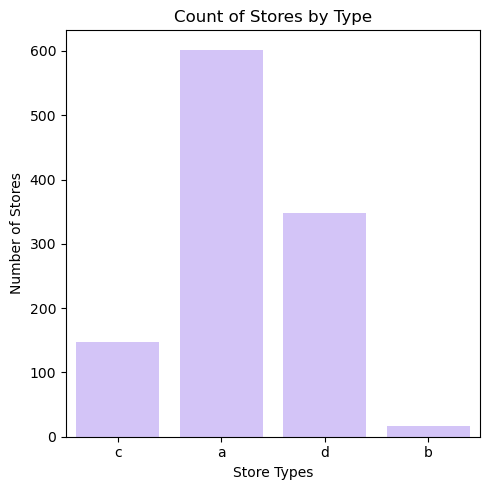

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.countplot(data=store_eda, x="StoreType", color=color(), ax=ax)

ax.set_xlabel("Store Types")
ax.set_ylabel("Number of Stores")
ax.set_title("Count of Stores by Type")

plt.tight_layout()
plt.show()

#### 🙉 Assortment type of all stores

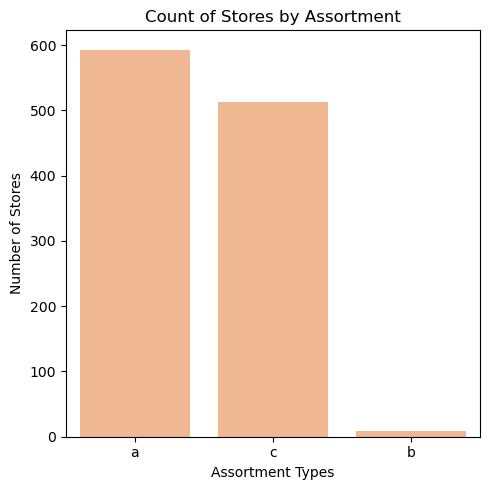

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.countplot(data=store_eda, x="Assortment", color=color(), ax=ax)

ax.set_xlabel("Assortment Types")
ax.set_ylabel("Number of Stores")
ax.set_title("Count of Stores by Assortment")

plt.tight_layout()
plt.show()

#### 🚦 Competition store's information

##### 😥 NAN

In [16]:
# Null detection
store_eda[store_eda["CompetitionDistance"].isna()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [17]:
train_eda[train_eda["Store"].isin([291, 622, 879])]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
290,291,5,2015-07-31,10052,973,1,1,0,1
621,622,5,2015-07-31,6306,540,1,1,0,1
878,879,5,2015-07-31,6000,466,1,1,0,0
1405,291,4,2015-07-30,9030,883,1,1,0,1
1736,622,4,2015-07-30,5412,406,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1015601,622,3,2013-01-02,4080,451,1,0,0,1
1015858,879,3,2013-01-02,3077,326,1,0,0,1
1016385,291,2,2013-01-01,0,0,0,0,a,1
1016716,622,2,2013-01-01,0,0,0,0,a,1


In [18]:
distance = store_eda.CompetitionDistance

distance.describe()

count     1112.000000
mean      5404.901079
std       7663.174720
min         20.000000
25%        717.500000
50%       2325.000000
75%       6882.500000
max      75860.000000
Name: CompetitionDistance, dtype: float64

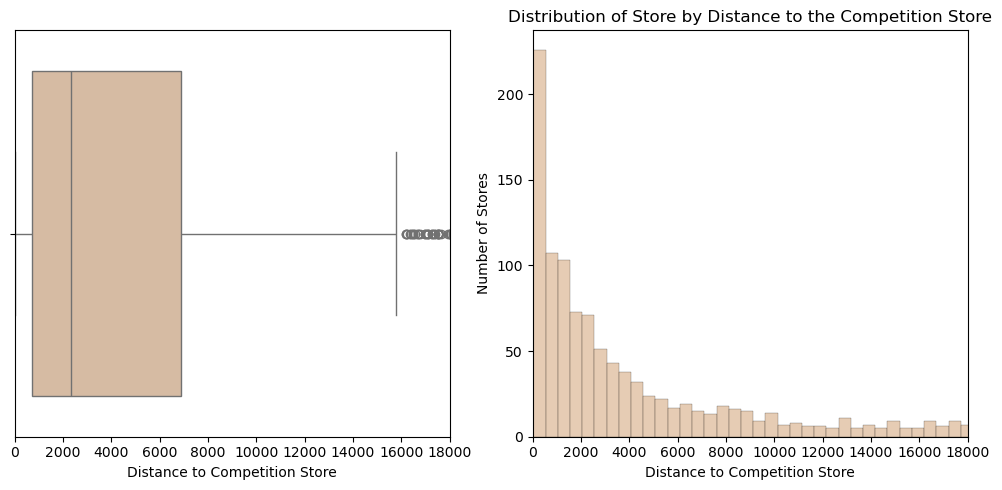

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.boxplot(data=store_eda, x="CompetitionDistance", color=c, ax=ax[0])

ax[0].set_xlabel("Distance to Competition Store")
ax[0].set_xlim((0, 18000))

sns.histplot(data=store_eda, x="CompetitionDistance", color=c, ax=ax[1], bins=150)

ax[1].set_xlabel("Distance to Competition Store")
ax[1].set_ylabel("Number of Stores")
ax[1].set_xlim((0, 18000))

plt.title("Distribution of Store by Distance to the Competition Store", loc="center")
plt.tight_layout()
plt.show()

##### 🇬🇧 The date the competition store was opened

In [20]:
store_eda.CompetitionOpenSinceYear.describe()

count     761.000000
mean     2008.668857
std         6.195983
min      1900.000000
25%      2006.000000
50%      2010.000000
75%      2013.000000
max      2015.000000
Name: CompetitionOpenSinceYear, dtype: float64

In [21]:
store_eda[store_eda.CompetitionOpenSinceYear.notna()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1108,1109,c,a,3490.0,4.0,2011.0,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"


In [22]:
store_eda.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


#### Ⓜ️ Long-term promotion's information

##### 📀 How many stores such that they have long-term promotion in the dataset?

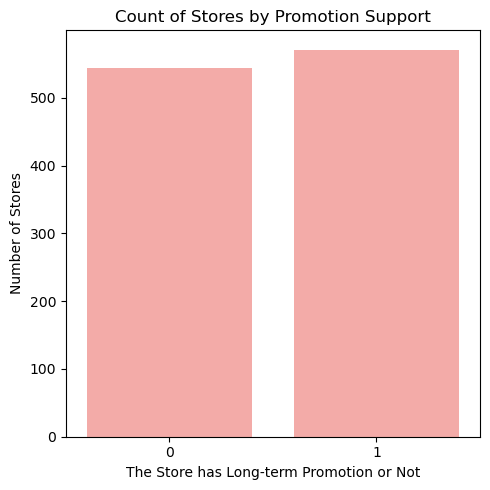

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.countplot(data=store_eda, x="Promo2", color=color(), ax=ax)

ax.set_xlabel("The Store has Long-term Promotion or Not")
ax.set_ylabel("Number of Stores")
ax.set_title("Count of Stores by Promotion Support")

plt.tight_layout()
plt.show()

In [24]:
store_eda[store_eda["Promo2"].notnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


##### 😋 The interval count, most stores will have promotion interval in which month

In [25]:
store_eda["NumPromoMonths"] = store_eda["PromoInterval"].dropna().apply(lambda x: len(x.split(",")))

In [26]:
store_eda.head()
store_eda = store_eda.drop(columns=["NumPromoMonths"])

### 🔩 Merge the store and its daily sales

In [27]:
store_eda.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 🦋 The information of daily of a store on a specific day

In [28]:
train_eda.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [29]:
train_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


In [30]:
train_eda.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846062,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [31]:
train_eda["Date"].describe()

count                       1017209
mean     2014-04-11 01:30:42.846062
min             2013-01-01 00:00:00
25%             2013-08-17 00:00:00
50%             2014-04-02 00:00:00
75%             2014-12-12 00:00:00
max             2015-07-31 00:00:00
Name: Date, dtype: object

#### ☄️ Combine/merge the two dataframes together, the sales' data will be linked with the store's information

In [32]:
merge_eda = train_eda.merge(right=store_eda, on="Store", how="left")

In [33]:
merge_eda.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [34]:
merge_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

In [35]:
merge_eda["Date"].describe()

count                       1017209
mean     2014-04-11 01:30:42.846062
min             2013-01-01 00:00:00
25%             2013-08-17 00:00:00
50%             2014-04-02 00:00:00
75%             2014-12-12 00:00:00
max             2015-07-31 00:00:00
Name: Date, dtype: object

#### 📊 Open == 0 -> Sales == 0

In [36]:
z_df = merge_eda[merge_eda["Sales"] == 0]

In [37]:
z_o_df = z_df[z_df["Open"] == 1]

In [38]:
z_o_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
86825,971,5,2015-05-15,0,0,1,0,0,1,c,a,1140.0,5.0,2011.0,1,14.0,2012.0,"Mar,Jun,Sept,Dec"
142278,674,4,2015-03-26,0,0,1,0,0,0,a,a,2640.0,12.0,2005.0,1,31.0,2013.0,"Feb,May,Aug,Nov"
196938,699,4,2015-02-05,0,0,1,1,0,0,a,a,180.0,NaN,NaN,1,5.0,2013.0,"Jan,Apr,Jul,Oct"
322053,708,3,2014-10-01,0,0,1,1,0,0,c,c,11470.0,10.0,2009.0,1,18.0,2014.0,"Jan,Apr,Jul,Oct"
330176,357,1,2014-09-22,0,0,1,0,0,0,a,a,2060.0,10.0,2008.0,0,NaN,NaN,NaN


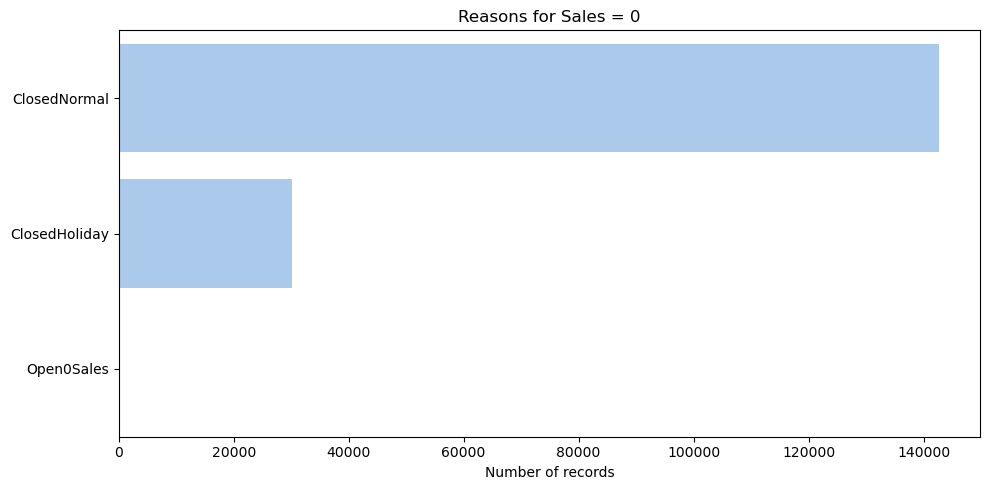

In [39]:
sales_0 = merge_eda[merge_eda["Sales"] == 0].copy()

def classify(row):
    if row["Open"] == 0:
        if row["StateHoliday"] in ["a", "b", "c"]:
            return "ClosedHoliday"
        else:
            return "ClosedNormal"
    else:
            return "Open0Sales"

sales_0["ZeroSalesReason"] = sales_0.apply(classify, axis=1)

# Plot
plt.figure(figsize=(10, 5))
order = sales_0["ZeroSalesReason"].value_counts().index

sns.countplot(
    data=sales_0,
    y="ZeroSalesReason",
    order=order,
    color=color()
)

plt.title("Reasons for Sales = 0")
plt.xlabel("Number of records")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [40]:
sales_0 = time_df[time_df["Sales"] == 0].copy()

closed_normal = sales_0[
    (sales_0["Open"] == 0) &
    (~sales_0["StateHoliday"].isin(["a", "b", "c"]))
].copy()

NameError: name 'time_df' is not defined

In [ ]:
merge_eda[merge_eda["Open"] == 0]["Sales"].describe()

count    172817.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Sales, dtype: float64

In [ ]:
merge_eda_valid_sales= merge_eda[merge_eda["Open"] == 1]

In [ ]:
len(merge_eda_valid_sales)

844392

#### 💦 Sales distribution

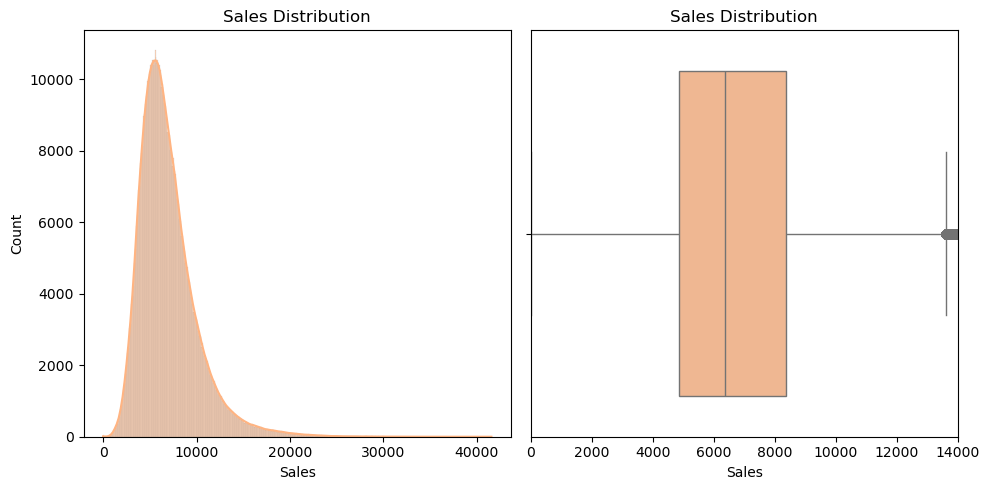

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.histplot(data=merge_eda_valid_sales, x="Sales", color=c, ax=axes[0], kde=True)

axes[0].set_xlabel("Sales")
# y is not the number of stores
# but the number of records for daily Sales
axes[0].set_title("Sales Distribution")

sns.boxplot(data=merge_eda_valid_sales, x="Sales", color=c, ax=axes[1])

axes[1].set_xlabel("Sales")
axes[1].set_title("Sales Distribution")
axes[1].set_xlim((-1, 14000))

plt.tight_layout()
plt.show()

In [ ]:
merge_eda.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 🥼 Stores'types and sales

In [ ]:
type_sales_df = merge_eda_valid_sales.groupby(by="StoreType")["Sales"].mean().reset_index()

In [ ]:
type_sales_df.head()

,StoreType,Sales
0,a,6925.167661
1,b,10231.407505
2,c,6932.512755
3,d,6822.141881


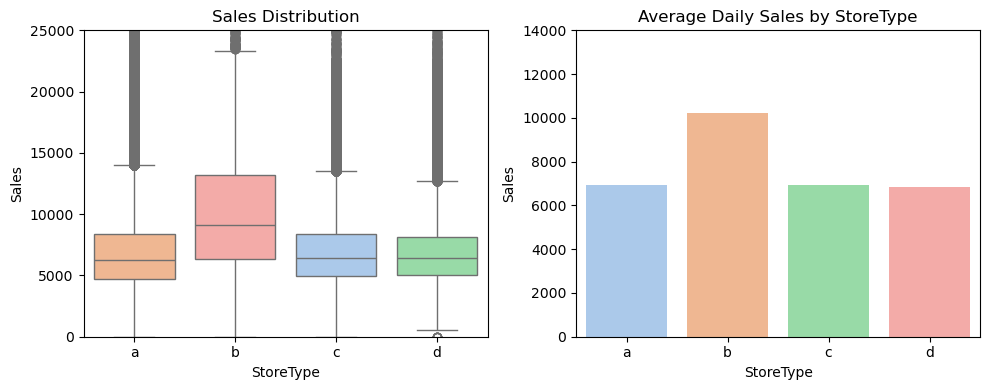

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
c = color()

sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="StoreType", ax=axes[0], hue="StoreType", order=["a", "b", "c", "d"], palette="pastel")

# y is not the number of stores
# but the number of records for daily Sales
axes[0].set_title("Sales Distribution")
axes[0].set_ylim((0, 25000))

sns.barplot(data=type_sales_df, x="StoreType", y="Sales", ax=axes[1], hue="StoreType", order=["a", "b", "c", "d"], palette="pastel")

axes[1].set_ylim((0, 14000))
axes[1].set_title("Average Daily Sales by StoreType")

plt.tight_layout()
plt.show()

In [ ]:
store_eda.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
merge_eda_valid_sales.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


---

#### 🧩 Assortment and Sales

In [ ]:
assortment_sales_df = merge_eda_valid_sales.groupby(by="Assortment")["Sales"].mean().reset_index()

In [ ]:
assortment_sales_df

,Assortment,Sales
0,a,6621.017039
1,b,8639.346322
2,c,7300.526339


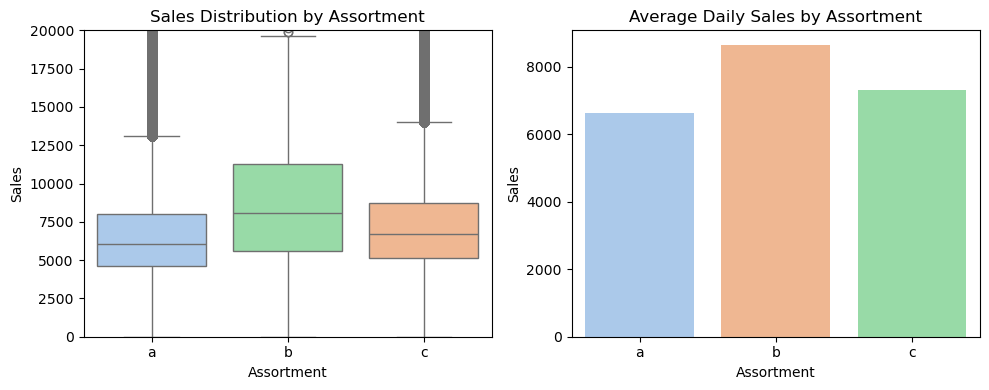

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
c = color()

sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="Assortment", ax=axes[0], hue="Assortment", order=["a", "b", "c"], palette="pastel")

# y is not the number of stores
# but the number of records for daily Sales
axes[0].set_title("Sales Distribution by Assortment")
axes[0].set_ylim((0, 20000))

sns.barplot(data=assortment_sales_df, x="Assortment", y="Sales", ax=axes[1], hue="Assortment", order=["a", "b", "c"], palette="pastel")

axes[1].set_ylim()
axes[1].set_title("Average Daily Sales by Assortment")

plt.tight_layout()
plt.show()

#### 🌵 CompetitionDistance and Sales

In [ ]:
competition_dis_df = merge_eda_valid_sales.copy()

In [ ]:
competition_dis_df.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  str           
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  str           
 10  Assortment                 844392 non-null  str           
 11  CompetitionDistance        842206 non-null  float64       
 12  Com

In [ ]:
competition_dis_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
store_sales = competition_dis_df[competition_dis_df["Open"] == 1].groupby("Store").agg({
    "Sales": "mean",
    "CompetitionDistance": "first"
}).reset_index()

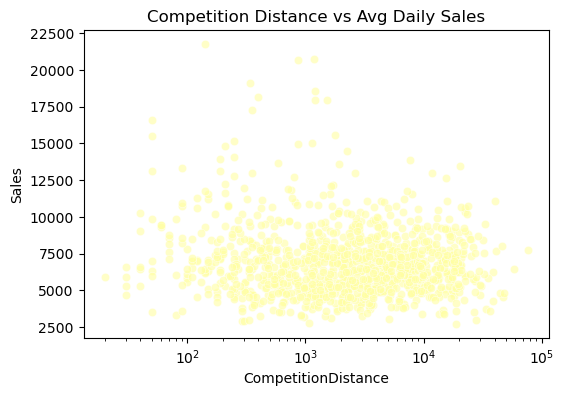

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=store_sales,
    x="CompetitionDistance",
    y="Sales",
    alpha=0.6,
    color=color(),
)

plt.xscale("log")
plt.title("Competition Distance vs Avg Daily Sales")
plt.show()

Text(0.5, 1.0, 'Trend between Competition Distance and Sales')

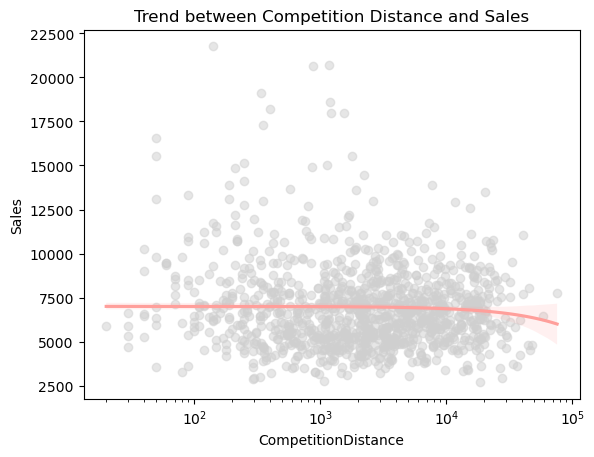

In [ ]:
sns.regplot(
    data=store_sales,
    x="CompetitionDistance",
    y="Sales",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": color()},
    color=color(),
)

plt.xscale("log")
plt.title("Trend between Competition Distance and Sales")

In [ ]:
merge_eda_valid_sales.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 🙉 DayOfWeek and Daily Sales

In [ ]:
dow_sales = merge_eda_valid_sales.groupby("DayOfWeek")["Sales"].mean().reset_index()

In [ ]:
dow_sales.head()

,DayOfWeek,Sales
0,1,8216.073074
1,2,7088.113656
2,3,6728.122978
3,4,6767.310159
4,5,7072.677012


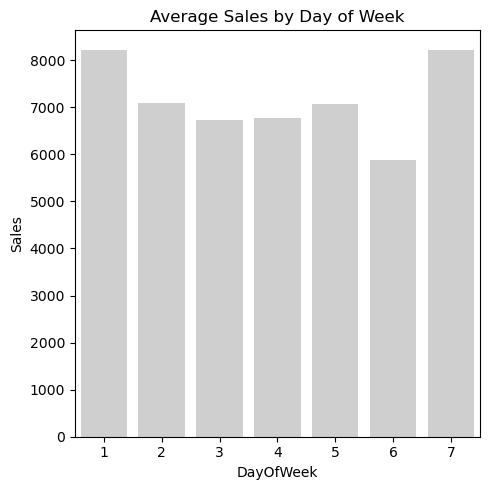

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(data=dow_sales, x="DayOfWeek", y="Sales", color=color(), ax=ax)


ax.set_title("Average Sales by Day of Week")

plt.tight_layout()
plt.show()

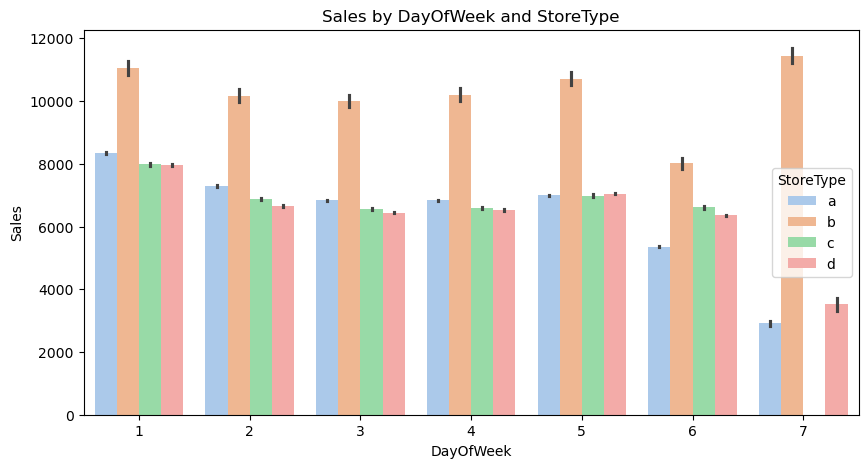

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merge_eda_valid_sales,
    x="DayOfWeek",
    y="Sales",
    hue="StoreType",
    palette="pastel",
    hue_order=["a", "b", "c", "d"],
)

plt.title("Sales by DayOfWeek and StoreType")
plt.show()

In [ ]:
store_c = merge_eda[merge_eda["StoreType"] == "c"]

In [ ]:
store_c_on_sunday = store_c[store_c["DayOfWeek"] == 7]

In [ ]:
store_c_on_sunday.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
5575,1,7,2015-07-26,0,0,0,0,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
5578,4,7,2015-07-26,0,0,0,0,0,0,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
5595,21,7,2015-07-26,0,0,0,0,0,0,c,c,550.0,10.0,1999.0,1,45.0,2009.0,"Jan,Apr,Jul,Oct"
5599,25,7,2015-07-26,0,0,0,0,0,0,c,a,430.0,4.0,2003.0,0,NaN,NaN,NaN
5608,34,7,2015-07-26,0,0,0,0,0,0,c,a,2240.0,9.0,2009.0,0,NaN,NaN,NaN


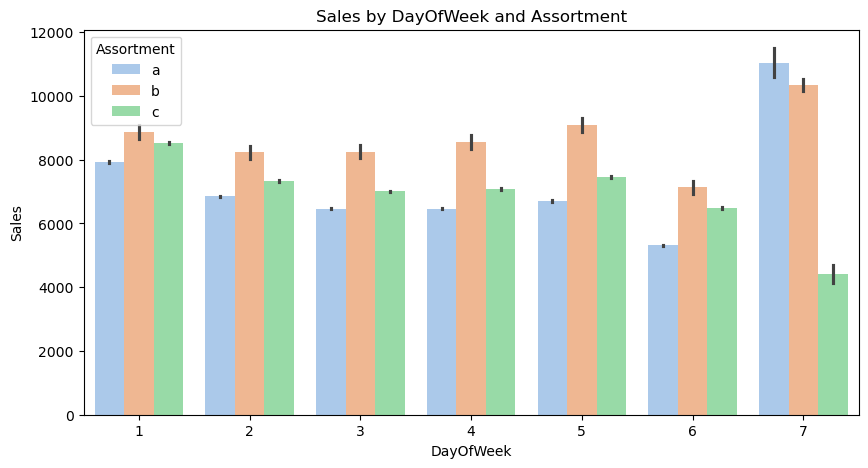

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merge_eda_valid_sales,
    x="DayOfWeek",
    y="Sales",
    hue="Assortment",
    hue_order=["a", "b", "c"],
    palette="pastel",
)

plt.title("Sales by DayOfWeek and Assortment")
plt.show()

#### 🇩🇯 StateHoliday v.s Daily Sales

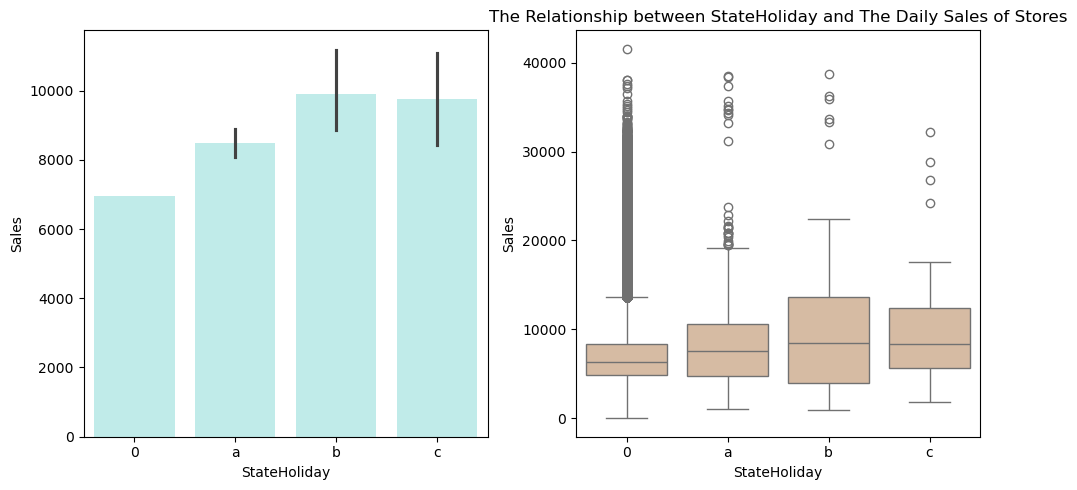

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.barplot(data=merge_eda_valid_sales, y="Sales", x="StateHoliday", ax=axes[0], order=["0", "a", "b", "c"], color=color())


sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="StateHoliday", ax=axes[1], order=["0", "a", "b", "c"], color=color())


plt.title("The Relationship between StateHoliday and The Daily Sales of Stores")
plt.tight_layout()
plt.show()

#### 🌵 StateHoliday, StoreType v.s Sales

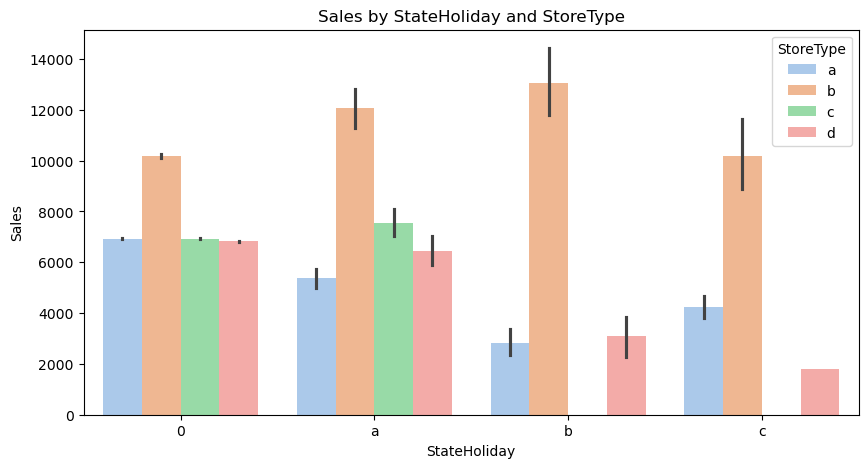

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merge_eda_valid_sales,
    x="StateHoliday",
    y="Sales",
    hue="StoreType",
    hue_order=["a", "b", "c", "d"],
    palette="pastel",
)

plt.title("Sales by StateHoliday and StoreType")
plt.show()

#### 🧃StateHoliday, Assortment v.s Sales

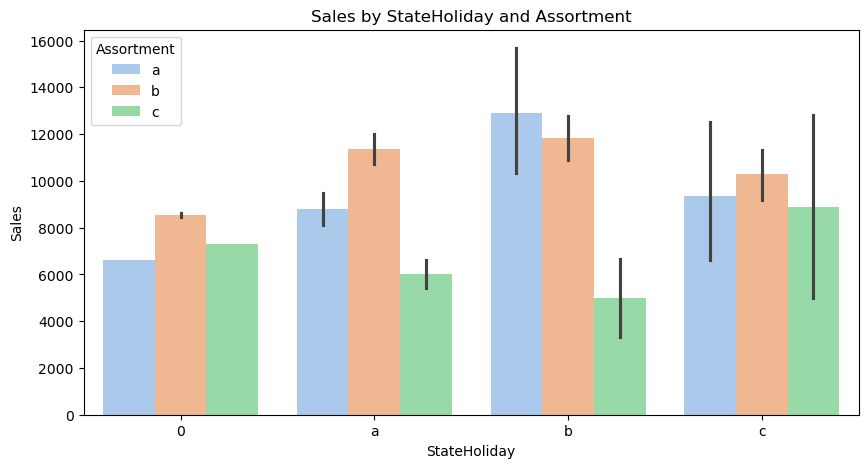

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merge_eda_valid_sales,
    x="StateHoliday",
    y="Sales",
    hue="Assortment",
    hue_order=["a", "b", "c"],
    palette="pastel",
)

plt.title("Sales by StateHoliday and Assortment")
plt.show()

In [ ]:
merge_eda_valid_sales.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 💇 Promotion / promotion2 v.s Sales

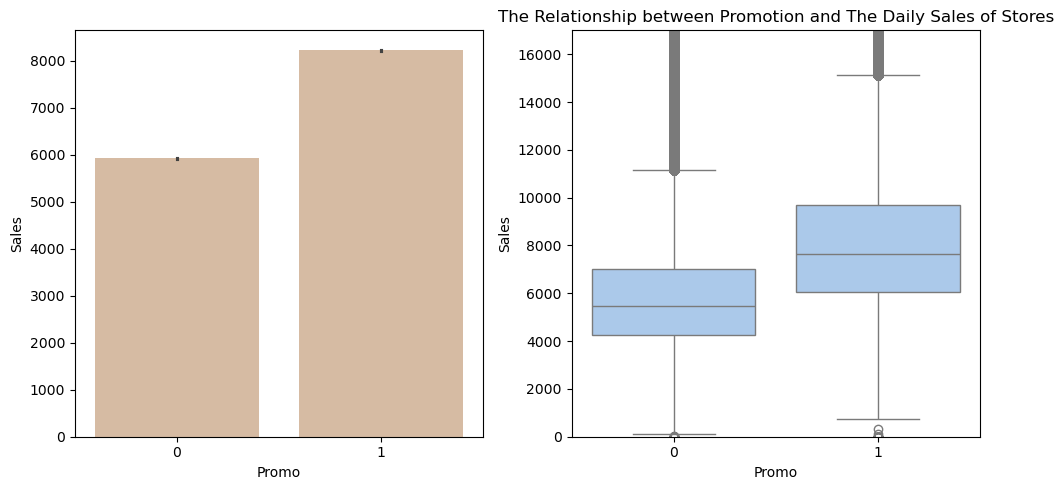

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.barplot(data=merge_eda_valid_sales, y="Sales", x="Promo", ax=axes[0], color=color())


sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="Promo", ax=axes[1], color=color())
axes[1].set_ylim((0, 17000))


plt.title("The Relationship between Promotion and The Daily Sales of Stores")
plt.tight_layout()
plt.show()

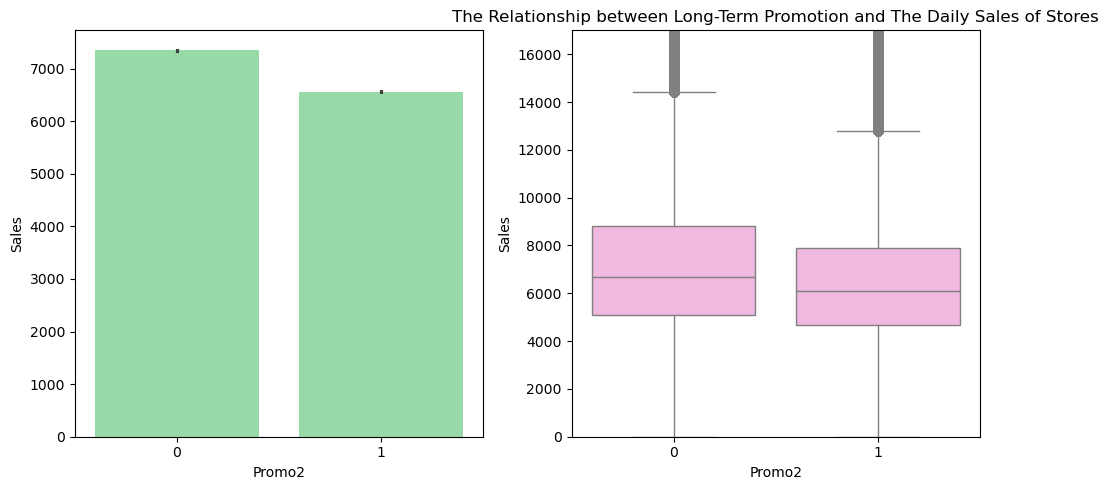

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.barplot(data=merge_eda_valid_sales, y="Sales", x="Promo2", ax=axes[0], color=color())


sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="Promo2", ax=axes[1], color=color())
axes[1].set_ylim((0, 17000))


plt.title("The Relationship between Long-Term Promotion and The Daily Sales of Stores")
plt.tight_layout()
plt.show()

##### 🈹 Promotion2 v.s Sales Time-aware, whether a day, a store has that Long-term promotion or not

In [ ]:
promo2 = merge_eda_valid_sales.copy()

In [ ]:
promo2["Year"] = promo2["Date"].dt.year
promo2["Week"] = promo2["Date"].dt.isocalendar().week
promo2["Month"] = promo2["Date"].dt.month

To check whether a promotion has started at that time or not:
- If they have the promotion
- Current year > the year
- Current week >=

In [ ]:
promo2["Promo2Started"] = (
    (promo2["Promo2"] == 1) &
    (
        (promo2["Year"] > promo2["Promo2SinceYear"]) |
        (
            (promo2["Year"] == promo2["Promo2SinceYear"]) &
            (promo2["Week"] >= promo2["Promo2SinceWeek"])
        )
    )
)

In [ ]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sept", 10: "Oct", 11: "Nov", 12: "Dec"
}

promo2["MonthStr"] = promo2["Month"].map(month_map)

In [ ]:
promo2["InPromoInterval"] = promo2.apply(
    lambda x: (
        isinstance(x["PromoInterval"], str) and
        x["MonthStr"] in x["PromoInterval"]
    ),
    axis=1
)

On that day, whether it has a long-term promotion active?

In [ ]:
promo2["Promo2Active"] = (
    promo2["Promo2Started"] & promo2["InPromoInterval"]
).astype(int)

In [ ]:
promo2.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Week,Month,Promo2Started,MonthStr,InPromoInterval,Promo2Active
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,NaN,NaN,NaN,2015,31,7,False,Jul,False,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,31,7,True,Jul,True,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,31,7,True,Jul,True,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,NaN,NaN,NaN,2015,31,7,False,Jul,False,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,NaN,NaN,NaN,2015,31,7,False,Jul,False,0


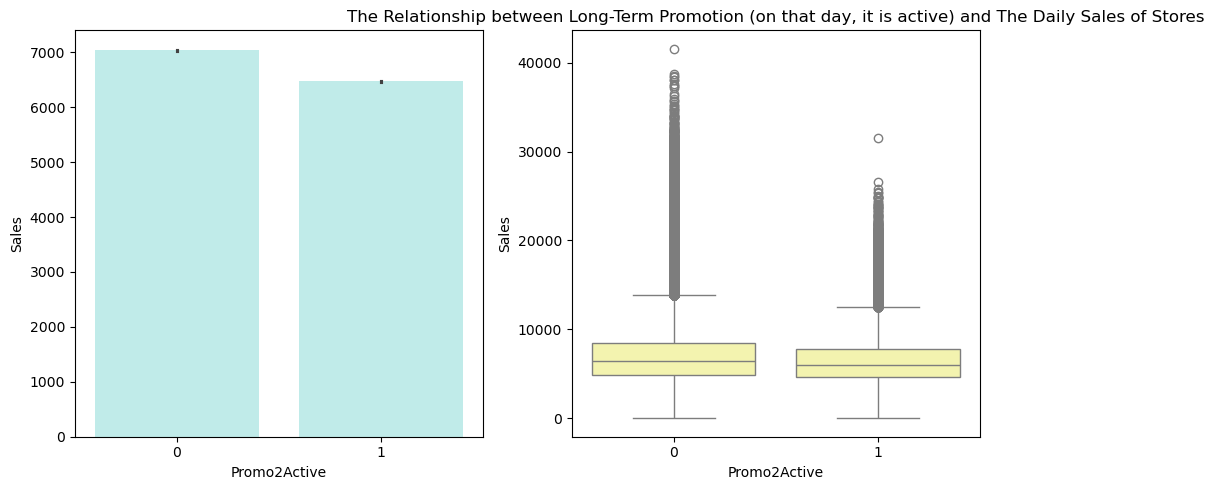

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.barplot(data=promo2, y="Sales", x="Promo2Active", ax=axes[0], color=color())


sns.boxplot(data=promo2, y="Sales", x="Promo2Active", ax=axes[1], color=color())


plt.title("The Relationship between Long-Term Promotion (on that day, it is active) and The Daily Sales of Stores")
plt.tight_layout()
plt.show()

#### 🥵 #Customers V.S Sales

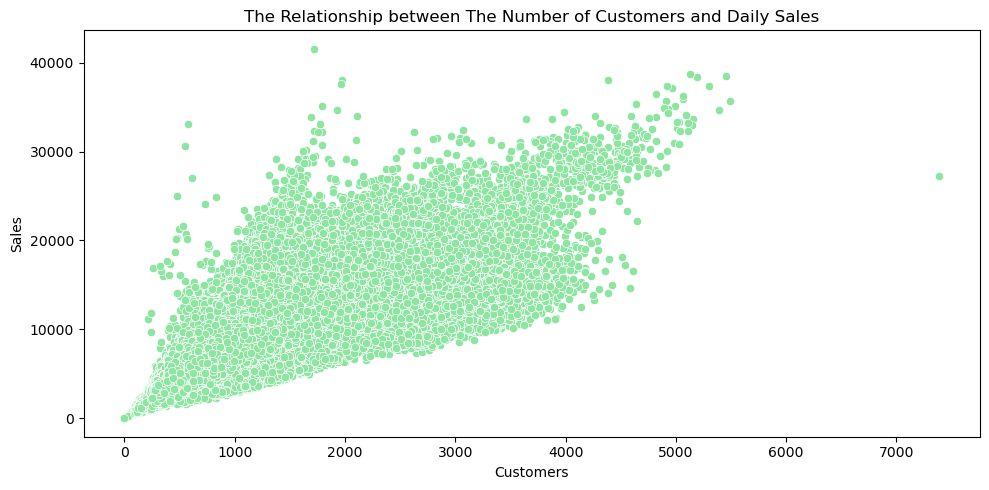

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
c = color()

sns.scatterplot(
        data=promo2, 
        y="Sales", 
        x="Customers", 
        ax=ax, 
        color=color(),
        # hue="StoreType", 
        # palette="pastel", 
        # hue_order=["a", "b", "c", "d"]
    )


plt.title("The Relationship between The Number of Customers and Daily Sales")
plt.tight_layout()
plt.show()

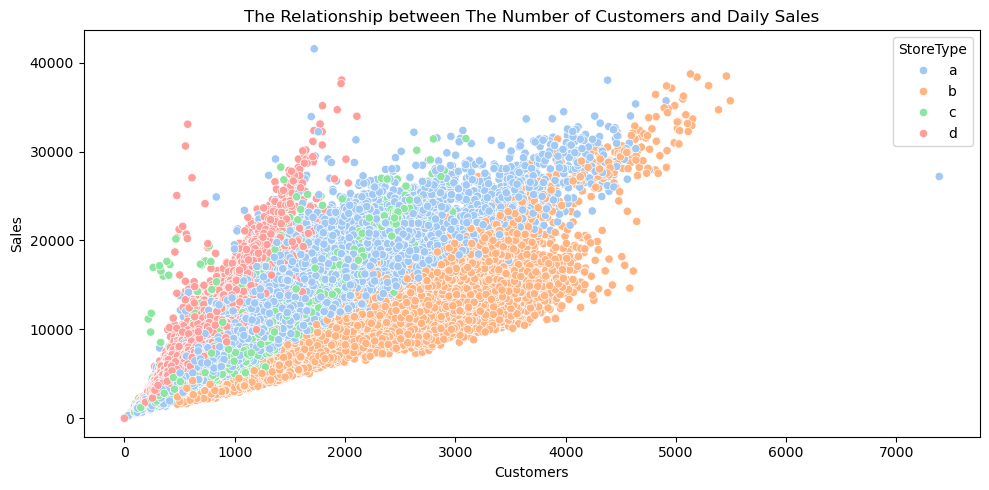

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
c = color()

sns.scatterplot(
        data=promo2, 
        y="Sales", 
        x="Customers", 
        ax=ax, 
        hue="StoreType", 
        palette="pastel", 
        hue_order=["a", "b", "c", "d"]
    )


plt.title("The Relationship between The Number of Customers and Daily Sales")
plt.tight_layout()
plt.show()

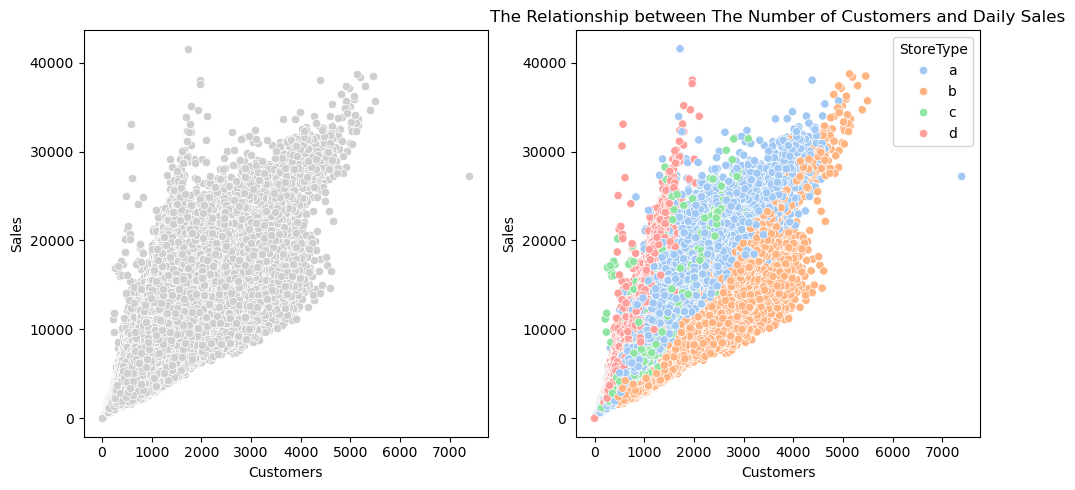

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

c = color()

sns.scatterplot(
        data=promo2, 
        y="Sales", 
        x="Customers", 
        ax=ax[0], 
        color=color(),
        # hue="StoreType", 
        # palette="pastel", 
        # hue_order=["a", "b", "c", "d"]
        # ax=ax[0]
    )

sns.scatterplot(
        data=promo2, 
        y="Sales", 
        x="Customers", 
        ax=ax[1], 
        hue="StoreType", 
        palette="pastel", 
        hue_order=["a", "b", "c", "d"],
        # ax=ax[1]
    )

plt.title("The Relationship between The Number of Customers and Daily Sales")
plt.tight_layout()
plt.show()

##### 🤑 Money per customers V.S StoreType

In [ ]:
money_df = merge_eda_valid_sales.copy()

In [ ]:
money_df["SalesPerCustomer"] = money_df["Sales"] / money_df["Customers"]

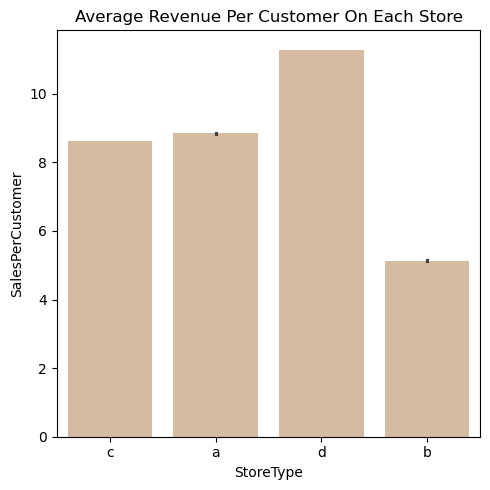

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(data=money_df, x="StoreType", y="SalesPerCustomer", color=color(), ax=ax)


ax.set_title("Average Revenue Per Customer On Each Store")

plt.tight_layout()
plt.show()

### 💙 Think about times/past events in EDA rather than current features -> current Sales

In [41]:
sns.set_theme(style="whitegrid")

In [42]:
time_df = merge_eda.copy()

In [43]:
time_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 💿 Time range

In [44]:
train_eda[train_eda["Date"] == "2013-01-05"].count()

Store            1115
DayOfWeek        1115
Date             1115
Sales            1115
Customers        1115
Open             1115
Promo            1115
StateHoliday     1115
SchoolHoliday    1115
dtype: int64

In [45]:
train_eda[train_eda["Date"] == "2014-12-31"].count()

Store            935
DayOfWeek        935
Date             935
Sales            935
Customers        935
Open             935
Promo            935
StateHoliday     935
SchoolHoliday    935
dtype: int64

In [46]:
time_df["Date"] = pd.to_datetime(time_df["Date"])

In [47]:
print("Min date:", time_df["Date"].min())
print("Max date:", time_df["Date"].max())
print("Total days span:", (time_df["Date"].max() - time_df["Date"].min()).days)

Min date: 2013-01-01 00:00:00
Max date: 2015-07-31 00:00:00
Total days span: 941


In [48]:
time_df[time_df["Date"] == "2013-01-01"].count()

Store                        1114
DayOfWeek                    1114
Date                         1114
Sales                        1114
Customers                    1114
Open                         1114
Promo                        1114
StateHoliday                 1114
SchoolHoliday                1114
StoreType                    1114
Assortment                   1114
CompetitionDistance          1111
CompetitionOpenSinceMonth     760
CompetitionOpenSinceYear      760
Promo2                       1114
Promo2SinceWeek               571
Promo2SinceYear               571
PromoInterval                 571
dtype: int64

#### 🙅‍♂️ Records per day

In [49]:
daily_counts = time_df.groupby("Date").size().reset_index(name="n_records")

In [50]:
daily_counts.describe()

,Date,n_records
count,942,942.000000
mean,2014-04-16 12:00:00,1079.839703
min,2013-01-01 00:00:00,935.000000
25%,2013-08-24 06:00:00,1115.000000
50%,2014-04-16 12:00:00,1115.000000
75%,2014-12-07 18:00:00,1115.000000
max,2015-07-31 00:00:00,1115.000000
std,NaN,71.399080


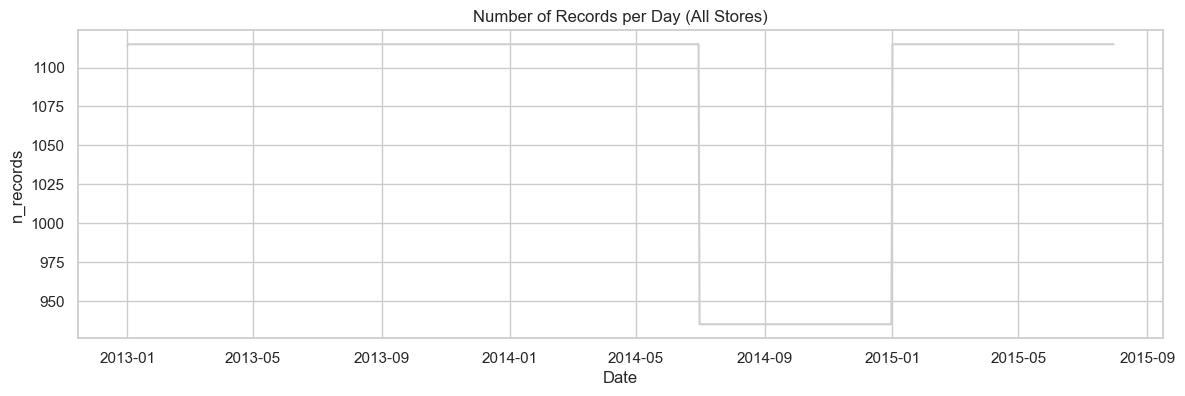

In [51]:
plt.figure(figsize=(14, 4))
sns.lineplot(data=daily_counts, x="Date", y="n_records", color=color())
plt.title("Number of Records per Day (All Stores)")
plt.show()

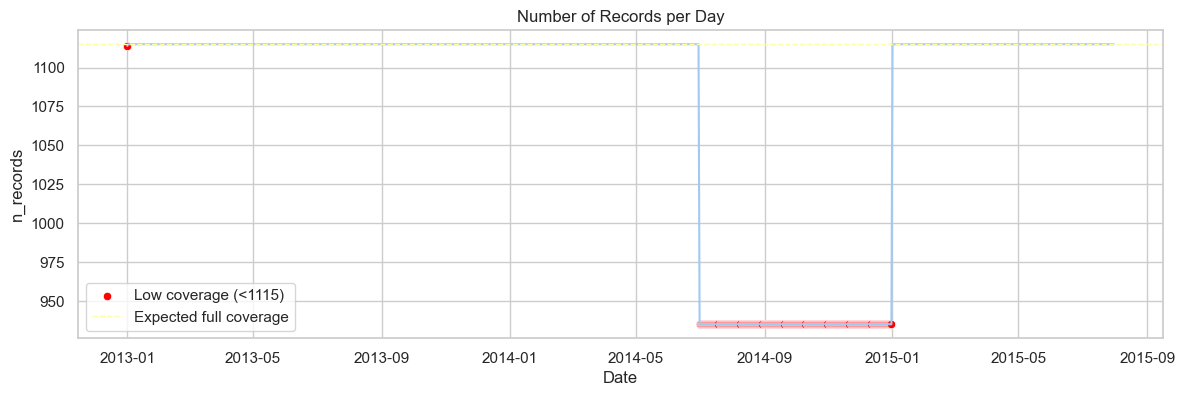

In [52]:
plt.figure(figsize=(14, 4))

sns.lineplot(data=daily_counts, x="Date", y="n_records", color=color())

low_coverage = daily_counts[daily_counts["n_records"] < 1115]

sns.scatterplot(
    data=low_coverage,
    x="Date",
    y="n_records",
    color="red",
    label="Low coverage (<1115)"
)

plt.axhline(1115, color=color(), linestyle="--", linewidth=1, label="Expected full coverage")

plt.title("Number of Records per Day")
plt.legend()
plt.show()

In [53]:
daily_counts[daily_counts["n_records"] < 1100].describe()

,Date,n_records
count,184,184.0
mean,2014-09-30 12:00:00,935.0
min,2014-07-01 00:00:00,935.0
25%,2014-08-15 18:00:00,935.0
50%,2014-09-30 12:00:00,935.0
75%,2014-11-15 06:00:00,935.0
max,2014-12-31 00:00:00,935.0
std,NaN,0.0


In [54]:
train_eda["Store"].describe()

count    1.017209e+06
mean     5.584297e+02
std      3.219087e+02
min      1.000000e+00
25%      2.800000e+02
50%      5.580000e+02
75%      8.380000e+02
max      1.115000e+03
Name: Store, dtype: float64

#### 🙉 Which stores are missing on a day?

In [55]:
all_stores = merge_eda["Store"].unique()

In [56]:
def missing_stores_on_date(df, target_date):
    target_date = pd.to_datetime(target_date)

    day_df = df[df["Date"] == target_date]
    present_stores = set(day_df["Store"].unique())
    
    missing = set(all_stores) - present_stores
    
    return missing

In [57]:
def missing_store_df(df):
    all_stores = set(df["Store"].unique())
    
    rows = []
    
    for date, group in df.groupby("Date"):
        present = set(group["Store"])
        missing = all_stores - present
        
        for store in missing:
            rows.append([date, store])
    
    return pd.DataFrame(rows, columns=["Date", "MissingStore"])

missing_df = missing_store_df(time_df)

In [58]:
missing_df.head()

,Date,MissingStore
0,2013-01-01,988
1,2014-07-01,512
2,2014-07-01,514
3,2014-07-01,1027
4,2014-07-01,518


In [59]:
missing_stores = missing_stores_on_date(time_df, "2014-07-01")

In [60]:
missing_period_df = time_df[(time_df["Date"] >= "2014-07-01") & (time_df["Date"] <= "2014-12-31")]

In [61]:
missing_period_df = missing_period_df.groupby(by="Date")["Sales"].mean().reset_index()

In [62]:
missing_period_df.head()

,Date,Sales
0,2014-07-01,8812.887701
1,2014-07-02,8244.486631
2,2014-07-03,7705.520856
3,2014-07-04,6971.890909
4,2014-07-05,5750.998930


In [63]:
missing_period_df["Date"].describe()

count                    184
mean     2014-09-30 12:00:00
min      2014-07-01 00:00:00
25%      2014-08-15 18:00:00
50%      2014-09-30 12:00:00
75%      2014-11-15 06:00:00
max      2014-12-31 00:00:00
Name: Date, dtype: object

In [64]:
missing_period_df["SameMissing"] = missing_period_df["Date"].apply(lambda d : missing_stores_on_date(time_df, d) == missing_stores_on_date(time_df, "2014-07-01"))

In [65]:
missing_period_df.head()

,Date,Sales,SameMissing
0,2014-07-01,8812.887701,True
1,2014-07-02,8244.486631,True
2,2014-07-03,7705.520856,True
3,2014-07-04,6971.890909,True
4,2014-07-05,5750.998930,True


In [66]:
missing_period_df["SameMissing"].describe()

count      184
unique       1
top       True
freq       184
Name: SameMissing, dtype: object

#### 🎃 Sales over time

💯 __ This is the actual Sales averaged by all stores on that day, regardless of the status of the stores __

In [67]:
mis_start = "2014-07-01"
mis_end = "2014-12-31"

In [68]:
missing_dates = time_df[(time_df["Date"] >= mis_start) & (time_df["Date"] <= mis_end)]

In [69]:
daily_sales = time_df.groupby("Date")["Sales"].sum().reset_index()

In [70]:
daily_sales_mis = missing_dates.groupby("Date")["Sales"].sum().reset_index()

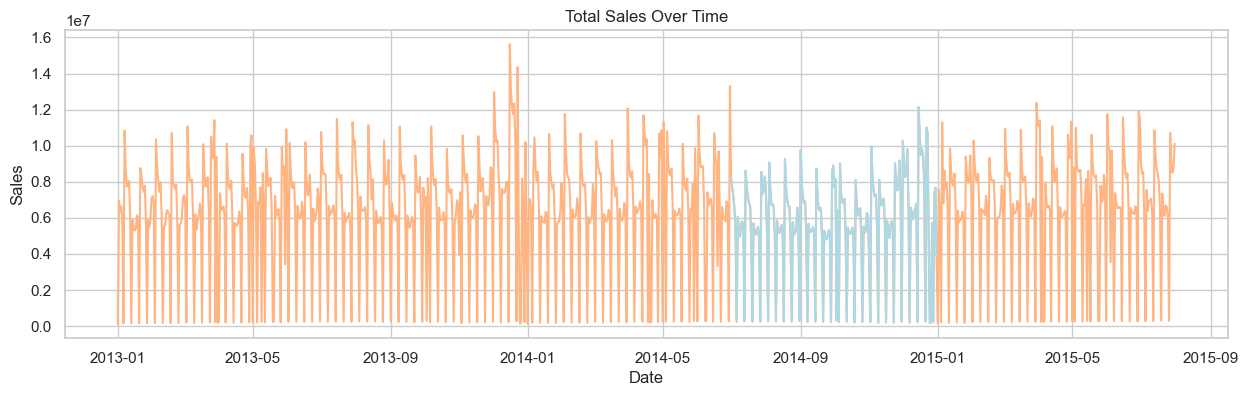

In [71]:
plt.figure(figsize=(15, 4))

sns.lineplot(data=daily_sales, x="Date", y="Sales", color=color())

sns.lineplot(data=daily_sales_mis, y="Sales", color="lightblue", x="Date")

plt.title("Total Sales Over Time")
plt.show()

#### 💿 Count the number of stores

In [90]:
time_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [72]:
store_count = time_df.groupby("Date")["Store"].nunique().reset_index()
store_count.columns = ["Date", "n_active_stores"]

In [73]:
store_count.head()

,Date,n_active_stores
0,2013-01-01,1114
1,2013-01-02,1115
2,2013-01-03,1115
3,2013-01-04,1115
4,2013-01-05,1115


In [74]:
store_count.describe()

,Date,n_active_stores
count,942,942.000000
mean,2014-04-16 12:00:00,1079.839703
min,2013-01-01 00:00:00,935.000000
25%,2013-08-24 06:00:00,1115.000000
50%,2014-04-16 12:00:00,1115.000000
75%,2014-12-07 18:00:00,1115.000000
max,2015-07-31 00:00:00,1115.000000
std,NaN,71.399080


In [75]:
daily_sales = time_df.groupby("Date")["Sales"].sum().reset_index()
daily = pd.merge(daily_sales, store_count, on="Date", how="left")
daily["sales_per_store"] = daily["Sales"] / daily["n_active_stores"]

In [76]:
daily.head()

,Date,Sales,n_active_stores,sales_per_store
0,2013-01-01,97235,1114,87.284560
1,2013-01-02,6949829,1115,6233.030493
2,2013-01-03,6347820,1115,5693.112108
3,2013-01-04,6638954,1115,5954.218834
4,2013-01-05,5951593,1115,5337.751570


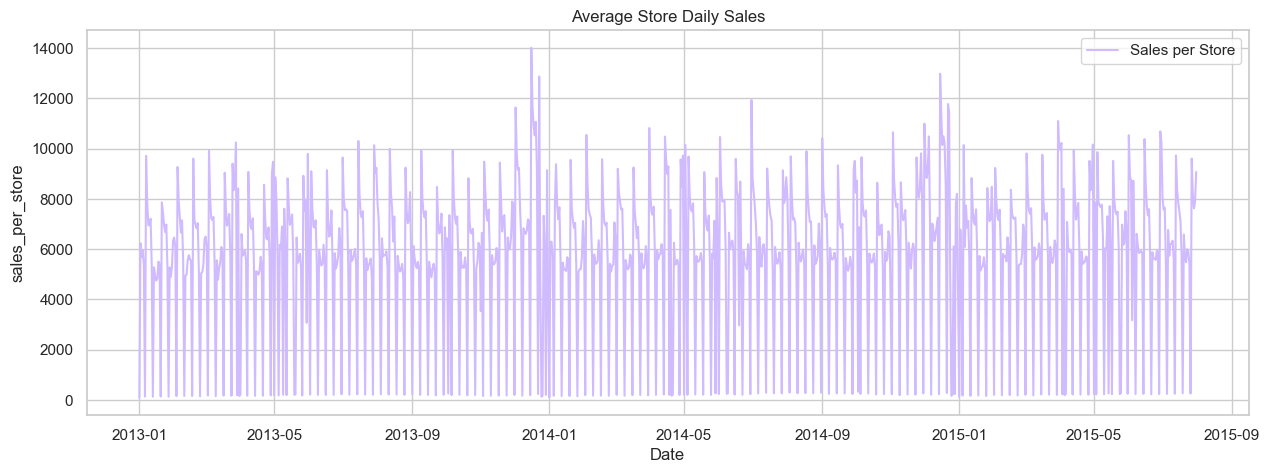

In [86]:
plt.figure(figsize=(15, 5))

# sns.lineplot(data=daily, x="Date", y="Sales", label="Total Sales (biased)")
sns.lineplot(data=daily, x="Date", y="sales_per_store", label="Sales per Store", color=color())

plt.title("Average Store Daily Sales")
plt.legend()
plt.show()

In [78]:
daily

,Date,Sales,n_active_stores,sales_per_store
0,2013-01-01,97235,1114,87.284560
1,2013-01-02,6949829,1115,6233.030493
2,2013-01-03,6347820,1115,5693.112108
3,2013-01-04,6638954,1115,5954.218834
4,2013-01-05,5951593,1115,5337.751570
...,...,...,...,...
937,2015-07-27,10707292,1115,9602.952466
938,2015-07-28,9115073,1115,8174.953363
939,2015-07-29,8499962,1115,7623.284305
940,2015-07-30,8798854,1115,7891.348879


#### 🤮 Rolling technique

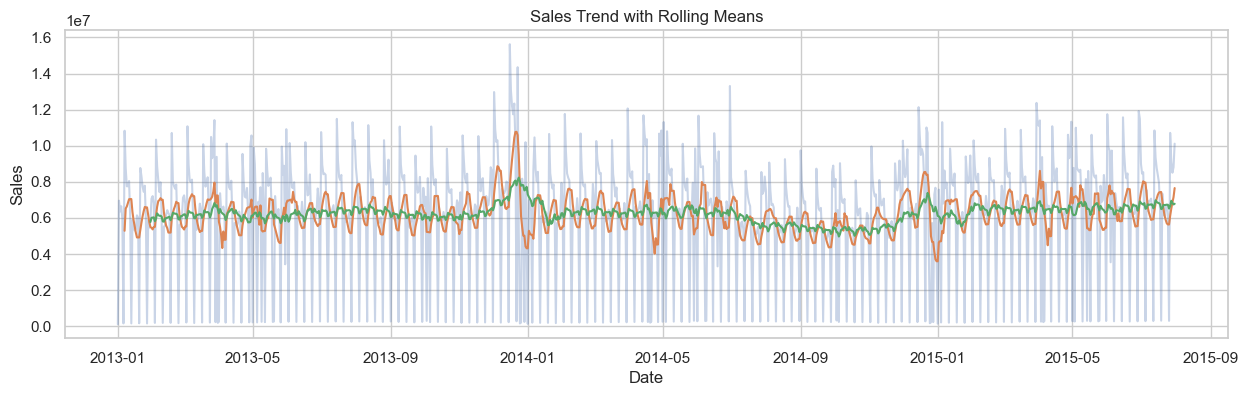

In [87]:
daily_sales["Sales_7d_ma"] = daily_sales["Sales"].rolling(7).mean()
daily_sales["Sales_30d_ma"] = daily_sales["Sales"].rolling(30).mean()

plt.figure(figsize=(15, 4))

sns.lineplot(data=daily_sales, x="Date", y="Sales", alpha=0.3)
sns.lineplot(data=daily_sales, x="Date", y="Sales_7d_ma")
sns.lineplot(data=daily_sales, x="Date", y="Sales_30d_ma")

plt.title("Sales Trend with Rolling Means")
plt.show()

In [109]:
daily_sales["sales_per_store"] = daily["sales_per_store"]

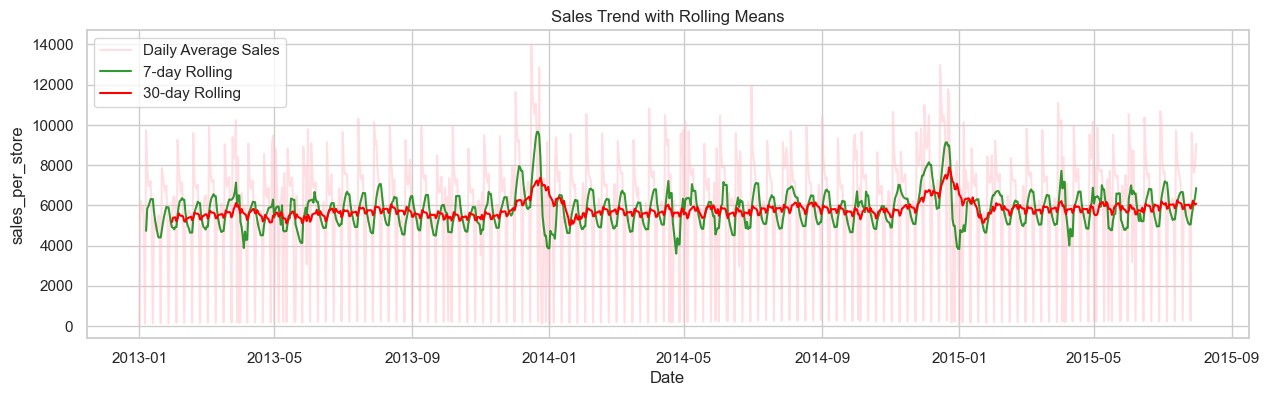

In [110]:
daily_sales["Sales_7d_ma"] = daily["sales_per_store"].rolling(7).mean()
daily_sales["Sales_30d_ma"] = daily["sales_per_store"].rolling(30).mean()
# daily_sales["Sales_90d_ma"] = daily["sales_per_store"].rolling(90).mean()

plt.figure(figsize=(15, 4))
sns.lineplot(data=daily_sales, x="Date", y="sales_per_store", alpha=0.5, color="pink", label="Daily Average Sales")
sns.lineplot(data=daily_sales, x="Date", y="Sales_7d_ma", alpha=0.8, color="green", label="7-day Rolling")
sns.lineplot(data=daily_sales, x="Date", y="Sales_30d_ma", color="red", label="30-day Rolling")
# sns.lineplot(data=daily_sales, x="Date", y="Sales_90d_ma", color="blue", label="90-day Rolling")

plt.title("Sales Trend with Rolling Means")
plt.show()

#### 🎹 Sales over time per StoreType

In [114]:
time_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [124]:
storetype_sales_df = time_df.groupby(["Date", "StoreType"])["Sales"].mean().reset_index()

- Has information about those stores -> Close, because of the business, low Sales understandable
- No information about those stores -> `Temporarilty` out of business -> Not reflect real Sales

In [125]:
storetype_sales_df.head()

,Date,StoreType,Sales
0,2013-01-01,a,4.836938
1,2013-01-01,b,5548.705882
2,2013-01-01,c,0.000000
3,2013-01-01,d,0.000000
4,2013-01-02,a,6512.269103


In [126]:
store_a = storetype_sales_df[storetype_sales_df["StoreType"] == "a"]
store_b = storetype_sales_df[storetype_sales_df["StoreType"] == "b"]
store_c = storetype_sales_df[storetype_sales_df["StoreType"] == "c"]
store_d = storetype_sales_df[storetype_sales_df["StoreType"] == "d"]

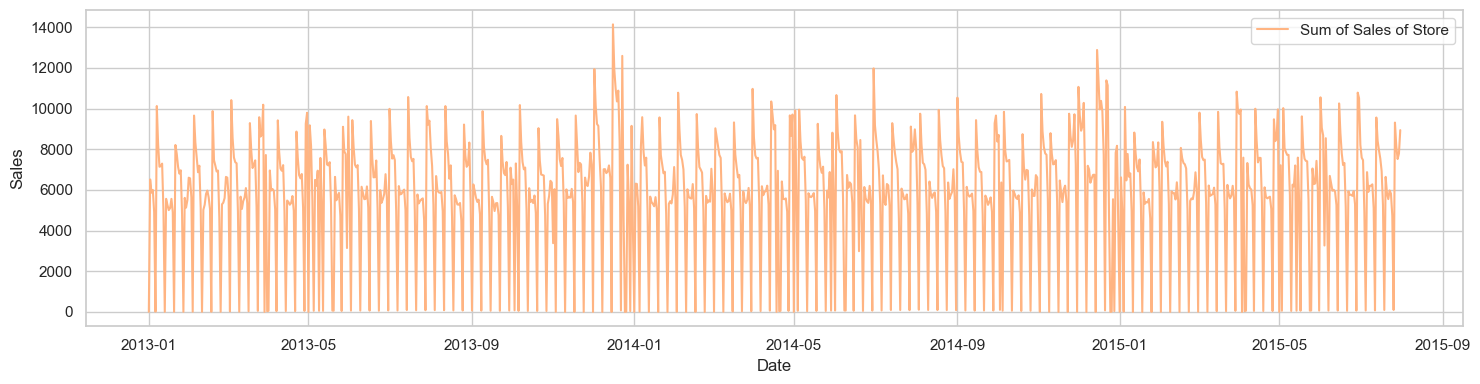

In [127]:
plt.figure(figsize=(15, 4))

sns.lineplot(data=store_a, x="Date", y="Sales", color=color(), label="Sum of Sales of Store")


plt.tight_layout()
plt.show()

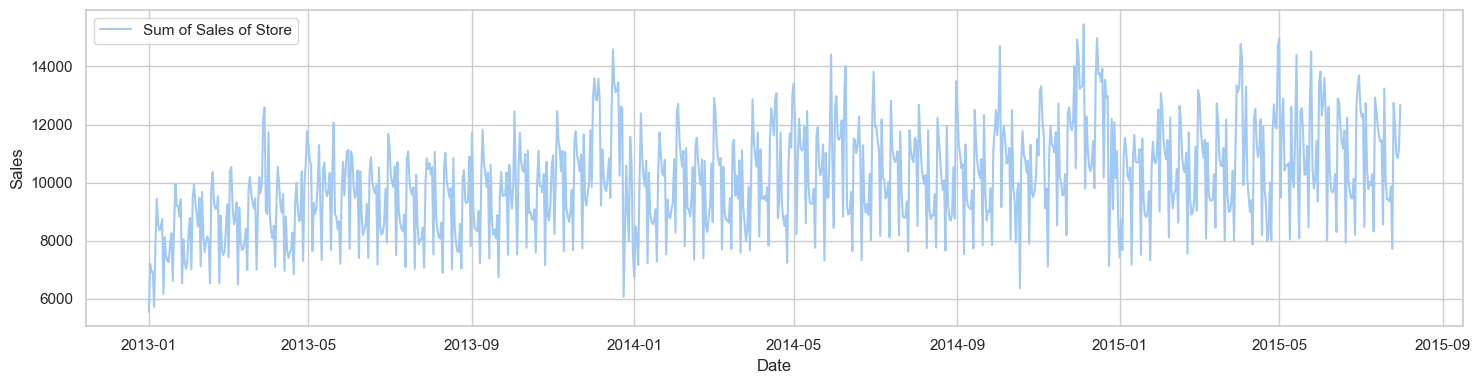

In [128]:
plt.figure(figsize=(15, 4))

sns.lineplot(data=store_b, x="Date", y="Sales", color=color(), label="Sum of Sales of Store")


plt.tight_layout()
plt.show()

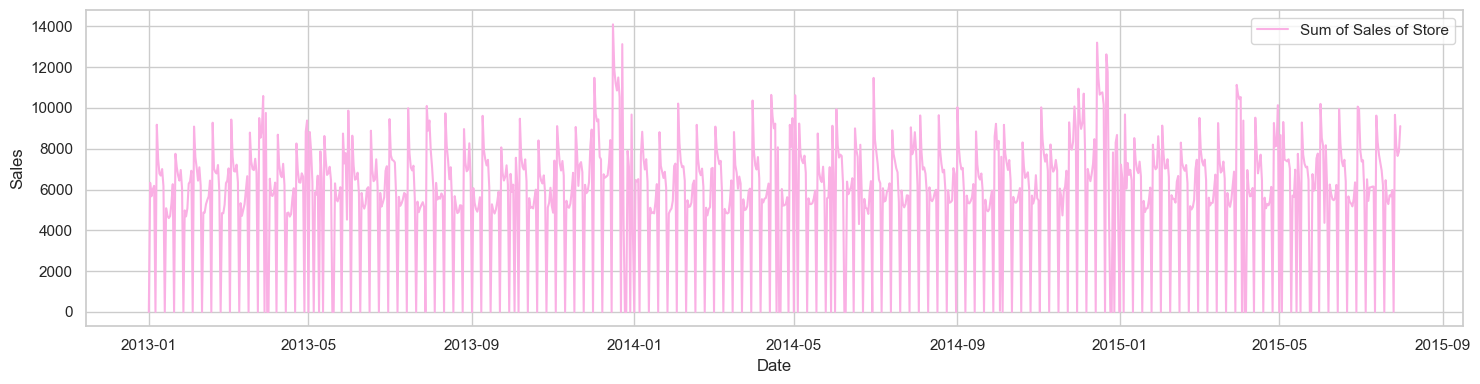

In [129]:
plt.figure(figsize=(15, 4))

sns.lineplot(data=store_c, x="Date", y="Sales", color=color(), label="Sum of Sales of Store")


plt.tight_layout()
plt.show()

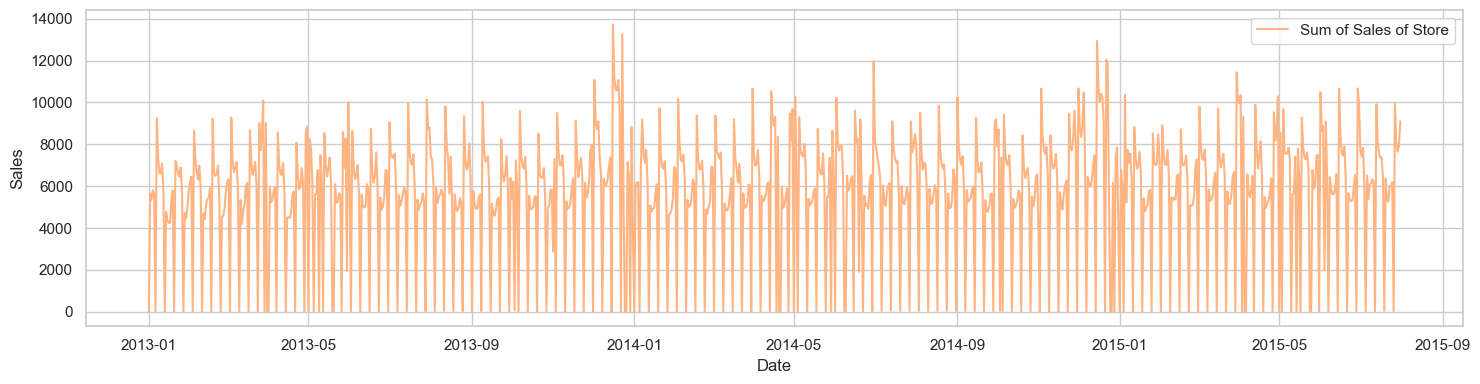

In [130]:
plt.figure(figsize=(15, 4))

sns.lineplot(data=store_d, x="Date", y="Sales", color=color(), label="Sum of Sales of Store")


plt.tight_layout()
plt.show()